In [ ]:
#ML Assignment 1 - Data Preprocessing
#The main objective of this project is to design and implement a robust data
#preprocessing system that addresses common challenges such as missing values, outliers,
#inconsistent formatting, and noise.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd

In [3]:
df=pd.read_csv("./drive/MyDrive/Data/Employee.csv")

In [4]:
df

,Company,Age,Salary,Place,Country,Gender
0,TCS,20.0,NaN,Chennai,India,0
1,Infosys,30.0,NaN,Mumbai,India,0
2,TCS,35.0,2300.0,Calcutta,India,0
3,Infosys,40.0,3000.0,Delhi,India,0
4,TCS,23.0,4000.0,Mumbai,India,0
...,...,...,...,...,...,...
143,TCS,33.0,9024.0,Calcutta,India,1
144,Infosys,22.0,8787.0,Calcutta,India,1
145,Infosys,44.0,4034.0,Delhi,India,1
146,TCS,33.0,5034.0,Mumbai,India,1


In [ ]:
#1. Data Exploration:
#Explore the data, list down the unique values in each feature and find its length.

In [5]:
for col in df.columns:
    unique_values = df[col].unique()
    num_unique = df[col].nunique()
    print(f"Feature: {col}")
    print(f"Number of unique values: {num_unique}")
    if num_unique < 50:  # Display all unique values if there are not too many
        print(f"Unique values: {unique_values}")
    else:
        print("Too many unique values to display all. Showing first 50:")
        print(f"Unique values (first 50): {unique_values[:50]}")
    print("\n" + "-"*50 + "\n")

Feature: Company
Number of unique values: 6
Unique values: ['TCS' 'Infosys' 'CTS' nan 'Tata Consultancy Services' 'Congnizant'
 'Infosys Pvt Lmt']

--------------------------------------------------

Feature: Age
Number of unique values: 29
Unique values: [20. 30. 35. 40. 23. nan 34. 45. 18. 22. 32. 37. 50. 21. 46. 36. 26. 41.
 24. 25. 43. 19. 38. 51. 31. 44. 33. 17.  0. 54.]

--------------------------------------------------

Feature: Salary
Number of unique values: 40
Unique values: [  nan 2300. 3000. 4000. 5000. 6000. 7000. 8000. 9000. 1089. 1234. 3030.
 3045. 3184. 4824. 5835. 7084. 8943. 8345. 9284. 9876. 2034. 7654. 2934.
 4034. 5034. 8202. 9024. 4345. 6544. 6543. 3234. 4324. 5435. 5555. 8787.
 3454. 5654. 5009. 5098. 3033.]

--------------------------------------------------

Feature: Place
Number of unique values: 11
Unique values: ['Chennai' 'Mumbai' 'Calcutta' 'Delhi' 'Podicherry' 'Cochin' nan 'Noida'
 'Hyderabad' 'Bhopal' 'Nagpur' 'Pune']

----------------------------------

In [ ]:
# Perform the statistical analysis and renaming of the columns.

In [6]:
print('Statistical Summary of Numerical Columns:')
display(df.describe())

print('\nData Types and Non-Null Counts:')
df.info()

Statistical Summary of Numerical Columns:


,Age,Salary,Gender
count,130.000000,124.000000,148.000000
mean,30.484615,5312.467742,0.222973
std,11.096640,2573.764683,0.417654
min,0.000000,1089.000000,0.000000
25%,22.000000,3030.000000,0.000000
50%,32.500000,5000.000000,0.000000
75%,37.750000,8000.000000,0.000000
max,54.000000,9876.000000,1.000000



Data Types and Non-Null Counts:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148 entries, 0 to 147
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Company  140 non-null    object 
 1   Age      130 non-null    float64
 2   Salary   124 non-null    float64
 3   Place    134 non-null    object 
 4   Country  148 non-null    object 
 5   Gender   148 non-null    int64  
dtypes: float64(2), int64(1), object(3)
memory usage: 7.1+ KB


In [ ]:
#2. Data Cleaning:
#Find the missing and inappropriate values, treat them appropriately.

### 2. Data Cleaning

First, I will standardize the 'Company' names to handle inconsistencies. Then, I will drop the 'Country' column as it contains only one unique value, making it redundant for analysis. Next, I will address missing values by filling them with appropriate strategies (mode for categorical, median for numerical). Finally, I will correct the inappropriate 'Age' value (0.0) by replacing it with the median age.

In [9]:
# Standardize 'Company' names
df['Company'] = df['Company'].replace({'Tata Consultancy Services': 'TCS', 'Infosys Pvt Lmt': 'Infosys', 'Congnizant': 'CTS'})

# Drop 'Country' column as it has only one unique value, only if it exists
if 'Country' in df.columns:
    df = df.drop('Country', axis=1)

# Impute missing values for 'Company' and 'Place' with mode
for col in ['Company', 'Place']:
    df[col] = df[col].fillna(df[col].mode()[0])

# Impute missing values for 'Age' and 'Salary' with median
for col in ['Age', 'Salary']:
    df[col] = df[col].fillna(df[col].median())

# Treat inappropriate 'Age' value (0.0) by replacing with the median age
df['Age'] = df['Age'].replace(0.0, df['Age'].median())

print("Data cleaning steps applied successfully!")
print("\nUpdated DataFrame Info:")
df.info()
print("\nFirst 5 rows of cleaned DataFrame:")
display(df.head())

Data cleaning steps applied successfully!

Updated DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148 entries, 0 to 147
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Company  148 non-null    object 
 1   Age      148 non-null    float64
 2   Salary   148 non-null    float64
 3   Place    148 non-null    object 
 4   Gender   148 non-null    int64  
dtypes: float64(2), int64(1), object(2)
memory usage: 5.9+ KB

First 5 rows of cleaned DataFrame:


,Company,Age,Salary,Place,Gender
0,TCS,20.0,5000.0,Chennai,0
1,Infosys,30.0,5000.0,Mumbai,0
2,TCS,35.0,2300.0,Calcutta,0
3,Infosys,40.0,3000.0,Delhi,0
4,TCS,23.0,4000.0,Mumbai,0


In [ ]:
#Remove all duplicate rows.

In [10]:
print(f"Number of rows before dropping duplicates: {len(df)}")
df.drop_duplicates(inplace=True)
print(f"Number of rows after dropping duplicates: {len(df)}")

print("\nDataFrame Info after dropping duplicates:")
df.info()
print("\nFirst 5 rows of DataFrame after dropping duplicates:")
display(df.head())

Number of rows before dropping duplicates: 148
Number of rows after dropping duplicates: 144

DataFrame Info after dropping duplicates:
<class 'pandas.core.frame.DataFrame'>
Index: 144 entries, 0 to 147
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Company  144 non-null    object 
 1   Age      144 non-null    float64
 2   Salary   144 non-null    float64
 3   Place    144 non-null    object 
 4   Gender   144 non-null    int64  
dtypes: float64(2), int64(1), object(2)
memory usage: 6.8+ KB

First 5 rows of DataFrame after dropping duplicates:


,Company,Age,Salary,Place,Gender
0,TCS,20.0,5000.0,Chennai,0
1,Infosys,30.0,5000.0,Mumbai,0
2,TCS,35.0,2300.0,Calcutta,0
3,Infosys,40.0,3000.0,Delhi,0
4,TCS,23.0,4000.0,Mumbai,0


In [ ]:
# Find the outliers

### 3. Outlier Detection

I will use the Interquartile Range (IQR) method to identify outliers in the numerical columns ('Age' and 'Salary'). Outliers are data points that fall below `Q1 - 1.5 * IQR` or above `Q3 + 1.5 * IQR`.

In [11]:
for column in ['Age', 'Salary']:
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]

    print(f"Outliers in '{column}' column:")
    if not outliers.empty:
        display(outliers[['Company', 'Age', 'Salary', 'Place', 'Gender']])
    else:
        print("No outliers found.")
    print("\n" + "-"*50 + "\n")

Outliers in 'Age' column:
No outliers found.

--------------------------------------------------

Outliers in 'Salary' column:
No outliers found.

--------------------------------------------------



In [ ]:
# Replace the value 0 in age as NaN Treat the null values in all columns using any
#measures(removing/ replace the values with mean/median/mode).

The value 0.0 in the 'Age' column was replaced with the median age.
All null values in 'Company', 'Place', 'Age', and 'Salary' columns were imputed using appropriate measures (mode for categorical, median for numerical).

In [ ]:
#3. Data Analysis:
# Filter the data with age >40 and salary<5000 Plot the chart with age and salary
#Count the number of people from each place and represent it visually

### 3. Data Analysis:

First, I will filter the dataset for employees with `Age > 40` and `Salary < 5000` and visualize the relationship between their age and salary using a scatter plot.

Filtered Data (Age > 40 and Salary < 5000):


,Company,Age,Salary,Place,Gender
21,Infosys,50.0,3184.0,Delhi,0
32,Infosys,45.0,4034.0,Calcutta,0
39,Infosys,41.0,3000.0,Mumbai,0
50,Infosys,41.0,3000.0,Chennai,0
57,Infosys,51.0,3184.0,Hyderabad,0
68,Infosys,43.0,4034.0,Mumbai,0
75,Infosys,44.0,3000.0,Cochin,0
86,Infosys,41.0,3000.0,Delhi,0
93,Infosys,54.0,3184.0,Mumbai,0
104,Infosys,44.0,4034.0,Delhi,0


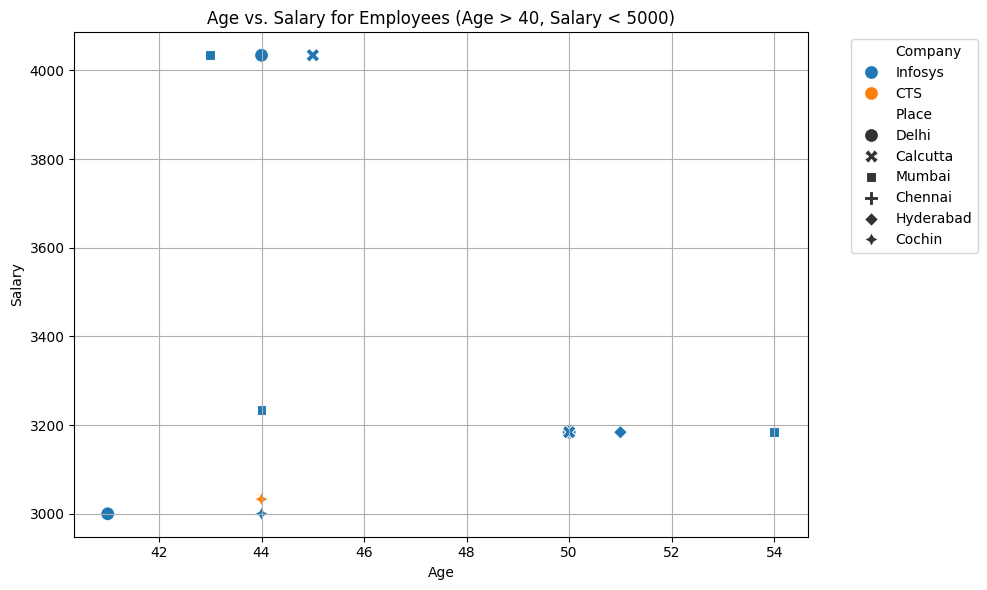

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter the data
filtered_df = df[(df['Age'] > 40) & (df['Salary'] < 5000)]

print("Filtered Data (Age > 40 and Salary < 5000):")
display(filtered_df)

# Plot Age vs. Salary for filtered data
plt.figure(figsize=(10, 6))
sns.scatterplot(data=filtered_df, x='Age', y='Salary', hue='Company', style='Place', s=100)
plt.title('Age vs. Salary for Employees (Age > 40, Salary < 5000)')
plt.xlabel('Age')
plt.ylabel('Salary')
plt.grid(True)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

Next, I will count the number of people from each 'Place' and represent it visually using a bar chart.

Number of people from each Place:


,Place,Count
0,Mumbai,48
1,Calcutta,32
2,Chennai,14
3,Delhi,14
4,Cochin,13
5,Noida,8
6,Hyderabad,8
7,Podicherry,3
8,Pune,2
9,Bhopal,1


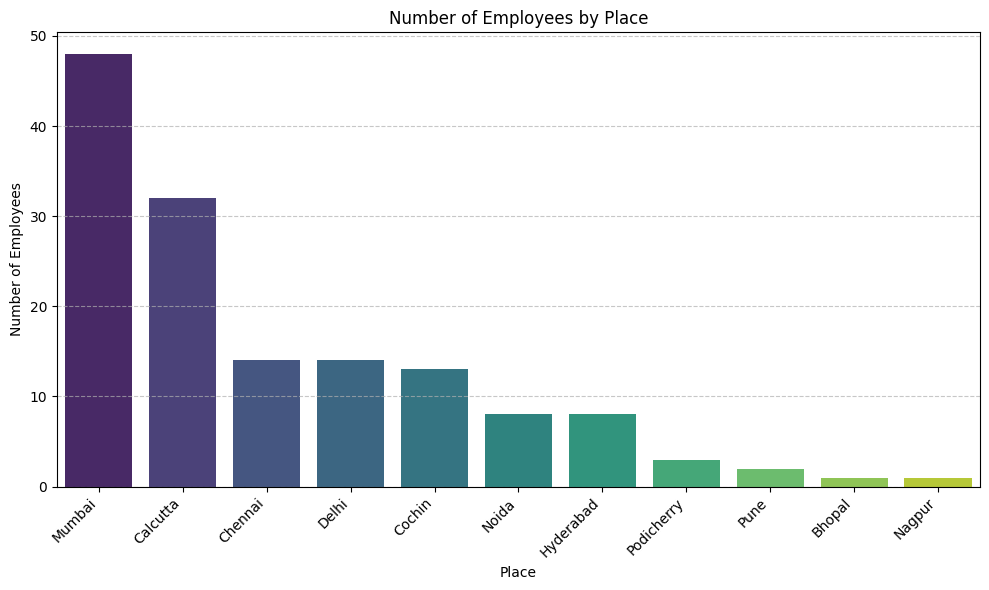

In [14]:
# Count people from each place
place_counts = df['Place'].value_counts().reset_index()
place_counts.columns = ['Place', 'Count']

print("Number of people from each Place:")
display(place_counts)

# Plot the count of people from each place
plt.figure(figsize=(10, 6))
sns.barplot(data=place_counts, x='Place', y='Count', hue='Place', palette='viridis', legend=False)
plt.title('Number of Employees by Place')
plt.xlabel('Place')
plt.ylabel('Number of Employees')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
#4. Data Encoding:
# Convert categorical variables into numerical representations using techniques
#such as one-hot encoding, label encoding, making them suitable for analysis by
#machine learning algorithms.

### 4. Data Encoding

I will use one-hot encoding to convert the categorical features 'Company' and 'Place' into a format suitable for machine learning algorithms. The 'Gender' column is already numerically encoded.

In [15]:
# Apply one-hot encoding to 'Company' and 'Place'
df_encoded = pd.get_dummies(df, columns=['Company', 'Place'], drop_first=True)

print("DataFrame after One-Hot Encoding:")
display(df_encoded.head())

print("\nUpdated DataFrame Info after encoding:")
df_encoded.info()

DataFrame after One-Hot Encoding:


,Age,Salary,Gender,Company_Infosys,Company_TCS,Place_Calcutta,Place_Chennai,Place_Cochin,Place_Delhi,Place_Hyderabad,Place_Mumbai,Place_Nagpur,Place_Noida,Place_Podicherry,Place_Pune
0,20.0,5000.0,0,False,True,False,True,False,False,False,False,False,False,False,False
1,30.0,5000.0,0,True,False,False,False,False,False,False,True,False,False,False,False
2,35.0,2300.0,0,False,True,True,False,False,False,False,False,False,False,False,False
3,40.0,3000.0,0,True,False,False,False,False,True,False,False,False,False,False,False
4,23.0,4000.0,0,False,True,False,False,False,False,False,True,False,False,False,False



Updated DataFrame Info after encoding:
<class 'pandas.core.frame.DataFrame'>
Index: 144 entries, 0 to 147
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Age               144 non-null    float64
 1   Salary            144 non-null    float64
 2   Gender            144 non-null    int64  
 3   Company_Infosys   144 non-null    bool   
 4   Company_TCS       144 non-null    bool   
 5   Place_Calcutta    144 non-null    bool   
 6   Place_Chennai     144 non-null    bool   
 7   Place_Cochin      144 non-null    bool   
 8   Place_Delhi       144 non-null    bool   
 9   Place_Hyderabad   144 non-null    bool   
 10  Place_Mumbai      144 non-null    bool   
 11  Place_Nagpur      144 non-null    bool   
 12  Place_Noida       144 non-null    bool   
 13  Place_Podicherry  144 non-null    bool   
 14  Place_Pune        144 non-null    bool   
dtypes: bool(12), float64(2), int64(1)
memory usage: 6.2 KB


In [ ]:
#5. Feature Scaling:
# After the process of encoding, perform the scaling of the features using
#standardscaler and minmaxscaler.

### 5. Feature Scaling

I will now apply `StandardScaler` and `MinMaxScaler` to the numerical features ('Age' and 'Salary') to transform them to a similar scale. This is important for many machine learning algorithms that are sensitive to the magnitude of feature values.

In [16]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# Identify numerical columns for scaling (excluding encoded boolean columns and Gender if it's already 0/1)
numerical_cols = ['Age', 'Salary']

# Create copies of the encoded DataFrame for each scaler to avoid modifying the original
df_standard_scaled = df_encoded.copy()
df_minmax_scaled = df_encoded.copy()

# Initialize StandardScaler and apply to numerical columns
scaler_standard = StandardScaler()
df_standard_scaled[numerical_cols] = scaler_standard.fit_transform(df_standard_scaled[numerical_cols])

print("DataFrame after StandardScaler (first 5 rows):")
display(df_standard_scaled.head())

print("\nStatistical Summary after StandardScaler:")
display(df_standard_scaled[numerical_cols].describe())

DataFrame after StandardScaler (first 5 rows):


,Age,Salary,Gender,Company_Infosys,Company_TCS,Place_Calcutta,Place_Chennai,Place_Cochin,Place_Delhi,Place_Hyderabad,Place_Mumbai,Place_Nagpur,Place_Noida,Place_Podicherry,Place_Pune
0,-1.475994,-0.100827,0,False,True,False,True,False,False,False,False,False,False,False,False
1,-0.257633,-0.100827,0,True,False,False,False,False,False,False,True,False,False,False,False
2,0.351548,-1.243735,0,False,True,True,False,False,False,False,False,False,False,False,False
3,0.960729,-0.947426,0,True,False,False,False,False,True,False,False,False,False,False,False
4,-1.110486,-0.524127,0,False,True,False,False,False,False,False,True,False,False,False,False



Statistical Summary after StandardScaler:


,Age,Salary
count,1.440000e+02,1.440000e+02
mean,-2.852656e-16,4.625929e-17
std,1.003490e+00,1.003490e+00
min,-1.841503e+00,-1.756350e+00
25%,-1.019109e+00,-9.283771e-01
50%,4.695768e-02,-1.008275e-01
75%,4.733842e-01,7.813277e-01
max,2.666435e+00,1.963179e+00


In [17]:
# Initialize MinMaxScaler and apply to numerical columns
scaler_minmax = MinMaxScaler()
df_minmax_scaled[numerical_cols] = scaler_minmax.fit_transform(df_minmax_scaled[numerical_cols])

print("DataFrame after MinMaxScaler (first 5 rows):")
display(df_minmax_scaled.head())

print("\nStatistical Summary after MinMaxScaler:")
display(df_minmax_scaled[numerical_cols].describe())

DataFrame after MinMaxScaler (first 5 rows):


,Age,Salary,Gender,Company_Infosys,Company_TCS,Place_Calcutta,Place_Chennai,Place_Cochin,Place_Delhi,Place_Hyderabad,Place_Mumbai,Place_Nagpur,Place_Noida,Place_Podicherry,Place_Pune
0,0.081081,0.445089,0,False,True,False,True,False,False,False,False,False,False,False,False
1,0.351351,0.445089,0,True,False,False,False,False,False,False,True,False,False,False,False
2,0.486486,0.137817,0,False,True,True,False,False,False,False,False,False,False,False,False
3,0.621622,0.217480,0,True,False,False,False,False,True,False,False,False,False,False,False
4,0.162162,0.331285,0,False,True,False,False,False,False,False,True,False,False,False,False



Statistical Summary after MinMaxScaler:


,Age,Salary
count,144.000000,144.000000
mean,0.408502,0.472197
std,0.222605,0.269790
min,0.000000,0.000000
25%,0.182432,0.222602
50%,0.418919,0.445089
75%,0.513514,0.682258
max,1.000000,1.000000
